In [1]:
# Usual Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import sklearn

# Librosa (the mother of audio files)
import librosa
import librosa.display
import IPython.display as ipd
import warnings
warnings.filterwarnings('ignore')

import os

In [2]:
os.environ['KAGGLE_CACHE_FOLDER'] = os.getcwd()  # or an absolute path
import kagglehub

# Download latest version
path = kagglehub.dataset_download("andradaolteanu/gtzan-dataset-music-genre-classification")

print("Path to dataset files:", path)

Path to dataset files: /Users/natallialantukh/.cache/kagglehub/datasets/andradaolteanu/gtzan-dataset-music-genre-classification/versions/1


In [4]:
data_path = os.path.join(os.getcwd(), 'Data/Data') #nested! get rid of it 
!ls "$data_path"

features_30_sec.csv features_3_sec.csv  genres_original     images_original


In [5]:
print(list(os.listdir(f'{data_path}/genres_original/')))

['pop', 'metal', 'disco', 'blues', 'reggae', 'classical', 'rock', 'hiphop', 'country', 'jazz']


# **Understanding Audio**


Let's first Explore our Audio Data to see how it looks.

Sound: sequence of vibrations in varying pressure strengths (y)

The sample rate (sr) is the number of samples of audio carried per second, measured in Hz or kHz


**What is a "sample"?**

Sound is a continuous wave in the air — pressure going up and down over time. A microphone converts that into a continuous electrical signal. But computers can't store continuous things — they need discrete numbers. So we snapshot (sample) the amplitude of the wave at regular intervals.

Each snapshot = one sample. It's just a number representing the wave's height at that exact moment in time.

**What does Hz actually mean here?**

Hz = "times per second" (Hertz = cycles per second, named after Heinrich Hertz).
So when you say 22,050 Hz sample rate, you mean: "take 22,050 snapshots of the audio wave every single second."
That's it. It's just a frequency — how often something happens per second.

1 Hz = once per second
1,000 Hz = 1 kHz = one thousand times per second
22,050 Hz = 22.05 kHz = twenty-two thousand and fifty times per second
44,100 Hz = 44.1 kHz = forty-four thousand one hundred times per second (CD quality)

kHz is just a shorthand — "kilo" means ×1000, so it keeps the numbers readable.

**Why does the rate matter so much?**

This is where it gets interesting. There's a foundational theorem in signal processing called the Nyquist-Shannon Sampling Theorem, and it says:

To accurately reconstruct a sound wave, your sample rate must be at least twice the highest frequency present in the audio.

Human hearing tops out at roughly 20,000 Hz (20 kHz). So to capture everything you can hear:
minimum sample rate = 2 × 20,000 Hz = 40,000 Hz
That's why CDs use 44,100 Hz — just comfortably above that threshold, with a small buffer. GTZAN uses 22,050 Hz, which means it can represent frequencies up to 11,025 Hz — still more than enough for capturing the dominant tonal and rhythmic content of music genres.

**Why GTZAN uses 22,050 Hz specifically**

It's exactly half of 44,100 Hz (CD quality). This was a common choice for archival/research audio because:

It cuts file size roughly in half vs. CD quality
It still captures the full perceptual range needed for genre classification (rhythm, harmony, timbre)
Genre ML models care more about spectral patterns than ultra-high-frequency detail

Amplitude (A) → physical size of the wave

Magnitude (|y|) → instant value (not used for loudness scale)

Decibels (dB) → human-friendly way to measure how loud it feels

In [ ]:
# import traceback                                                                                                                                  
                                                                                                                                                    
# try:                                                                                                                                              
#     y, sr = librosa.load(f'{data_path}/genres_original/pop/pop.00036.wav')                                                                        
# except Exception as e:
#     traceback.print_exc()

In [6]:
genres = list(os.listdir(f'{data_path}/genres_original/'))
track_id = '00036'
audio = {}

for genre in genres:
    try:
        y, sr = librosa.load(f'{data_path}/genres_original/{genre}/{genre}.{track_id}.wav')
        audio[genre] = {
            'y': librosa.effects.trim(y)[0],
            'sr': sr
        }
    except Exception as e:
        print(f"Error loading {genre}: {e}")

In [7]:
# Importing 1 file
y, sr = librosa.load(f'{data_path}/genres_original/reggae/reggae.00036.wav')

print('y:', y, '\n')
print('y shape:', np.shape(y), '\n')
print('Sample Rate (KHz):', sr, '\n')

# Verify length of the audio
print('Check Len of Audio:', 661794/22050)

y: [0.02072144 0.04492188 0.05422974 ... 0.06912231 0.08303833 0.08572388] 

y shape: (661794,) 

Sample Rate (KHz): 22050 

Check Len of Audio: 30.013333333333332


In [8]:
colors = ['#A300F9', '#F90000', '#00F9A3', '#F9A300', '#0044F9',
          '#F900A3', '#00F944', '#F9F900', '#00A3F9', '#A3F900']


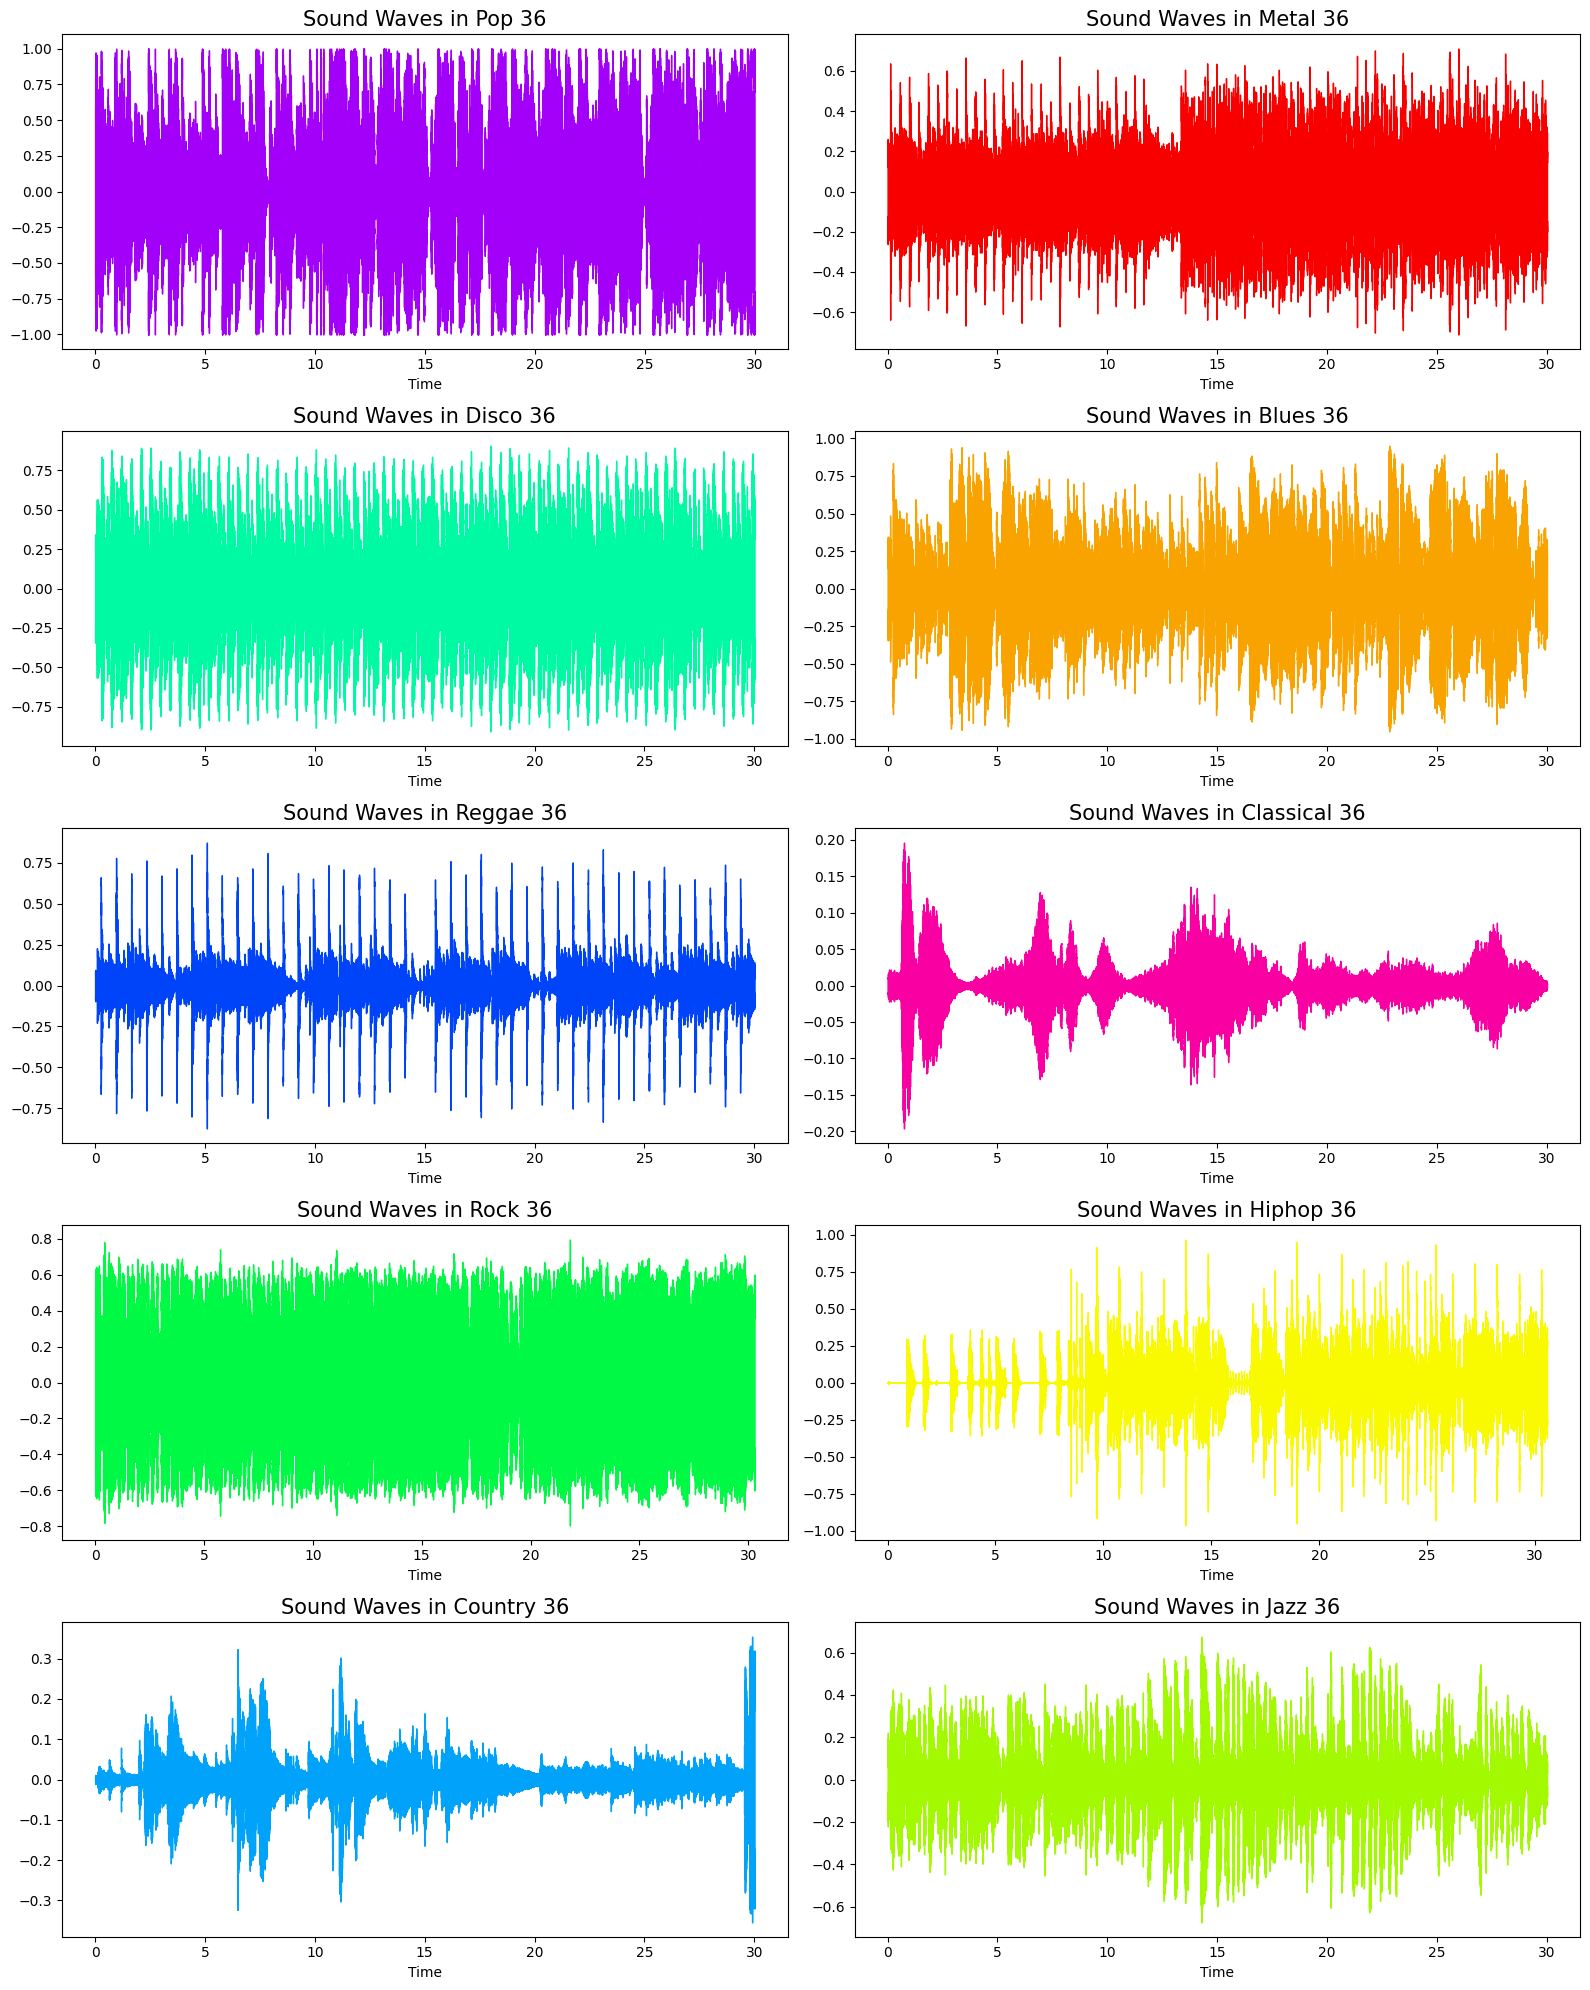

In [9]:
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(16, 20))

for (genre, color), ax in zip(zip(audio.keys(), colors), axes.flatten()):
    librosa.display.waveshow(y=audio[genre]['y'], sr=audio[genre]['sr'], color=color, ax=ax)
    ax.set_title(f"Sound Waves in {genre.capitalize()} 36", fontsize=15)

plt.tight_layout()
plt.show()

In [ ]:
audio['jazz']


# **Fourier Transform**
Function that gets a signal in the time domain as input, and outputs its decomposition into frequencies

Transform both the y-axis (frequency) to log scale, and the “color” axis (amplitude) to Decibels, which is approx. the log scale of amplitudes.

**The core problem Fourier Transform solves**


A raw audio waveform (what you've been plotting with waveshow) shows you amplitude over time — but it tells you nothing about which frequencies are present. You can see the wave going up and down, but you can't tell if it's a bass guitar or a violin just from that shape.

Fourier Transform answers: "what mix of frequencies makes up this signal?"
The mathematical insight is that any complex wave can be decomposed into a sum of simple sine waves, each with its own frequency and amplitude. FT finds those components.


complex wave = sine at 440Hz + sine at 880Hz + sine at 1320Hz + ...


So the input is your waveform (amplitude vs time), and the output is a spectrum (amplitude vs frequency). You trade the time axis for a frequency axis.

**The problem with a plain Fourier Transform**

A full FT gives you frequencies across the entire signal at once — you lose all time information. You'd know the song contains a 440Hz note, but not when it plays. Useless for music analysis.

**STFT — Short-Time Fourier Transform**

The fix is simple: slice the audio into short overlapping windows, then run FT on each window separately.
This is what librosa.stft() does. Now you get frequency information over time — a 2D output where:

rows = frequencies

columns = time windows

That's your D matrix.

In [10]:
# Default FFT window size
n_fft = 2048 # FFT window size
hop_length = 512 # number audio of frames between STFT columns (looks like a good default)

# Short-time Fourier transform (STFT)
D = np.abs(librosa.stft(audio['jazz']['y'], n_fft = n_fft, hop_length = hop_length))

print('Shape of D object:', np.shape(D))

Shape of D object: (1025, 1293)


**The two parameters explained:**

n_fft = 2048 — the window size in samples. Each slice of audio is 2048 samples long before FT is applied. This controls the frequency resolution — larger window = more frequency detail, but less time precision.

**2048 samples ÷ 22050 sr ≈ 0.093 seconds per window**

hop_length = 512 — how many samples to slide forward between windows.

Since windows overlap (2048 size, 512 hop), consecutive columns share most of their samples, giving you smooth time resolution.

**overlap = 2048 - 512 = 1536 samples shared between adjacent windows**

window 1: |----2048----|


window 2:****|----2048----|


window 3:********|----2048----|


              ^512^ hop

D = np.abs(librosa.stft(audio_file, n_fft=n_fft, hop_length=hop_length))
print('Shape of D object:', np.shape(D))
# → (1025, N)


- **1025 rows** = frequency bins (= `n_fft/2 + 1`)
- **N columns** = time frames (= total samples ÷ hop_length)

`np.abs()` is applied because the raw STFT output is **complex numbers** (they encode both amplitude and phase). Taking the absolute value gives you just the **magnitude** — how strong each frequency is at each moment.

---

## The log scales — why both axes get transformed

**Y-axis → log scale (frequencies)**

Human pitch perception is logarithmic. The jump from 100Hz to 200Hz *sounds* the same size as 1000Hz to 2000Hz — both are one octave. On a linear scale, the low frequencies get crushed into a tiny sliver while high frequencies dominate the plot. Log scale matches how we actually hear.

**Color axis → Decibels (amplitudes)**

Same idea. Human loudness perception is also logarithmic — this is why dB exists at all. A signal at 0.001 amplitude and one at 0.1 amplitude are perceptually very different, but on a linear color scale they'd look almost identical. Converting to dB:

dB = 20 × log10(amplitude)


This spreads out the quiet details and compresses the loud peaks into a range your eyes (and the model) can meaningfully interpret.

---

**The full picture**


        Raw audio (time domain) ↓  

        ↓  STFT (slice into windows + FT each)↓  

        D matrix (frequency × time, complex numbers)↓  

        ↓  np.abs()↓  

        Magnitude spectrogram↓  

        ↓  convert to dB + log frequency axis↓  

        Spectrogram you can visualize and feed to a model

**The catch — you can't have perfect resolution on both axes simultaneously**



This is the deep part. There's an unavoidable trade-off:

Longer window → better frequency resolution, worse time resolution

n_fft = 4096  → can distinguish 440Hz vs 441Hz precisely
               but can only say "it happened somewhere in this 0.18s window"

Shorter window → better time resolution, worse frequency resolution

n_fft = 256   → can pinpoint the note to within 0.01s
               but can't tell if it's 440Hz or 445Hz

This is directly analogous to the Heisenberg uncertainty principle in physics — the more precisely you know one thing, the less precisely you can know the other. Here it's time vs frequency instead of position vs momentum.

n_fft = 2048 is simply a well-established middle ground that works well for music — good enough on both axes for genre classification purposes.

*440Hz is just the musical note A4, the A above middle C on a piano.*

**Times calculated as n_fft / sr = 2048 / 22050 ≈ 0.093s**

For music specifically, 2048 hits the sweet spot because:

**Music has notes that typically last 100ms or more** — so a 93ms window captures a meaningful musical moment without blurring too many notes together

You need fine enough frequency resolution to distinguish musical pitches — remember C4 is 261Hz and D4 is 293Hz, only 32Hz apart. Too small an n_fft and those blur into one blob

Genre classification cares about both rhythm (needs time resolution) and harmony/timbre (needs frequency resolution) — 2048 respects both

When you play a single note on any instrument, within that ~93ms window the FFT is essentially doing what your ear does naturally — decomposing the complex sound into its frequency components:

you play C4 on a guitar
↓
FFT sees:
  261.63 Hz  ████████████  (fundamental — loudest, this is the "pitch")

  523.25 Hz  ██████        (1st overtone — C5)

  784.88 Hz  ████          (2nd overtone — G5)

  1046.50 Hz ███           (3rd overtone — C6)

  1308.13 Hz ██            (4th overtone — E6)
  
  ...getting quieter each time

That specific shape of overtone loudness is what makes a guitar sound like a guitar and not a piano. A musician would call it timbre or tone color. Signal processing calls it the spectral envelope.

# **The Spectrogram**

What is a spectrogram? A spectrogram is a visual representation of the spectrum of frequencies of a signal as it varies with time. When applied to an audio signal, spectrograms are sometimes called sonographs, voiceprints, or voicegrams.
Here we convert the frequency axis to a logarithmic one.

In [ ]:
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(16, 20))

for (genre, color), ax in zip(zip(audio.keys(), colors), axes.flatten()):
    D = np.abs(librosa.stft(audio[genre]['y'], n_fft = n_fft, hop_length = hop_length))
    DB = librosa.amplitude_to_db(D, ref = np.max)
    # S = librosa.feature.melspectrogram(y=audio[genre]['y'], sr=audio[genre]['sr'], n_fft=n_fft, hop_length=hop_length)
    # S_DB = librosa.amplitude_to_db(S, ref=np.max)
    img = librosa.display.specshow(DB, sr=sr, hop_length=hop_length,
                                   x_axis='time', y_axis='log', cmap='cool', ax=ax)
    img = librosa.display.specshow(DB, sr = sr, hop_length = hop_length, x_axis = 'time', y_axis = 'log',
                        cmap = 'cool')
    fig.colorbar(img, ax=ax)
    ax.set_title(f"{genre.capitalize()} Spectrogram", fontsize=15)

plt.tight_layout()
plt.show()


## **Mel Spectrogram**


The Mel Scale, mathematically speaking, is the result of some non-linear transformation of the frequency scale. The Mel Spectrogram is a normal Spectrogram, but with a Mel Scale on the y axis.

A regular spectrogram spaces frequencies linearly — equal pixel distance between every 100Hz step:

0 Hz
100 Hz  ← 100Hz gap

200 Hz  ← 100Hz gap

300 Hz  ← 100Hz gap

...

10000 Hz

10100 Hz ← 100Hz gap

10200 Hz ← 100Hz gap


But as a musician you know that's not how pitch actually works. The jump from A2 (110Hz) to A3 (220Hz) sounds like one octave — the same as the jump from A4 (440Hz) to A5 (880Hz). Both are one octave, but the first is a 110Hz gap and the second is a 440Hz gap.
On a linear scale those two octaves look completely different in size. But perceptually they are identical.

In [ ]:
audio['jazz']['sr']

In [ ]:
audio.keys()

In [ ]:
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(16, 20))

for (genre, color), ax in zip(zip(audio.keys(), colors), axes.flatten()):
    S = librosa.feature.melspectrogram(y=audio[genre]['y'], sr=audio[genre]['sr'], n_fft=n_fft, hop_length=hop_length)
    S_DB = librosa.amplitude_to_db(S, ref=np.max)
    img = librosa.display.specshow(S_DB, sr=audio[genre]['sr'], hop_length=hop_length,
                                   x_axis='time', y_axis='log', cmap='cool', ax=ax)
    fig.colorbar(img, ax=ax)
    ax.set_title(f"{genre.capitalize()} Mel Spectrogram", fontsize=15)

plt.tight_layout()
plt.show()

# **Audio Features**

## **1. Zero Crossing Rate**

the rate at which the signal changes from positive to negative or back.

In [ ]:
# Total zero_crossings in our 1 song
zero_crossings = librosa.zero_crossings(audio['jazz']['y'], pad=False)
print(sum(zero_crossings))

## **2. Harmonic and Percussive**

Harmonics are frequency components that the ear doesn't separate into individual pitches, but instead fuses into a single tone color. (represents the sound color).

Harmonics and overtones are essentially the same thing — the extra frequencies produced alongside the fundamental when an instrument plays a note. The subtle difference:

you play C4 (261.63 Hz)

fundamental:    261.63 Hz  → 1st harmonic

1st overtone:   523.25 Hz  → 2nd harmonic

2nd overtone:   784.88 Hz  → 3rd harmonic

3rd overtone:   1046.50 Hz → 4th harmonic


"Overtone" counts from 1 above the fundamental. "Harmonic" counts including the fundamental. Same frequencies, different numbering convention.
Timbre is the result — the overall tone color you perceive because of the specific mix of harmonics. It's not a frequency itself, it's the personality of the sound that emerges from the harmonic profile.

**Why it matters for genre classification**

Different genres have characteristic harmonic profiles:

classical strings  → smooth harmonic decay, each overtone quieter than the last

distorted guitar   → harsh, dense harmonics, many overtones at similar loudness

jazz piano         → rich mid harmonics, warm fundamental

electronic synth   → can have any harmonic profile, often unnaturally perfect


---



When you hit a drum, pluck a string, or strike a piano key, the sound has two distinct phases:

attack (transient)    → sudden spike in energy, very short, broadband

sustain/decay         → the note ringing, harmonic content, slower




---



harmonic, percussive = librosa.effects.hpss(audio['jazz']['y'])


**Harmonic component** — the tonal, pitched content

sustained notes, chords, melody, overtones
→ smooth horizontal streaks on a spectrogram (stable frequencies over time)


**Percussive component** — the rhythmic, transient content

drums, attacks, clicks, plucks
→ sharp vertical streaks on a spectrogram (sudden energy across all frequencies)


Visually on a spectrogram:

**harmonic looks like:  **       


freq ────────────────        

freq ────────────────        

freq  ───────────────        

freq   ──────────────        

          time →                   



**percussive looks like:**

freq  |    |      |         |

freq  |    |      |         |

freq  |    |      |         |

freq  |    |      |         |

       time →


Horizontal = sustained frequency = harmonic

Vertical = sudden broadband burst = percussive


---

## "Rhythm and emotion"

**Rhythm** part is straightforward — percussive transients are literally where the beat lives. Your brain locks onto those spikes to feel the groove.

**Emotion** part is more interesting. Research in music psychology shows:

fast transient attacks   → excitement, aggression, energy  (metal, punk)


slow soft attacks        → calm, melancholy, intimacy      (classical, ambient)


dense rhythmic transients → urgency, danceability          (disco, reggae)


sparse transients        → space, contemplation            (jazz ballads)


So the percussive component carries emotional information not through pitch or harmony, but through **how energy arrives over time** — the shape and density of those shock waves.

---

## Why this matters for genre classification

Different genres have very characteristic percussive profiles:

metal      → dense, aggressive transients, fast attack, distorted

reggae     → offbeat emphasis (skank), laid back transients

classical  → soft attacks, minimal percussion, transients from bow/key

disco      → four-on-the-floor kick pattern, strong regular transients

jazz       → light brush strokes, irregular syncopated transients



When you separate harmonic and percussive components and feed both to a model, you're giving it **two complementary views** of the same audio:

harmonic component  → tells the model about: pitch, timbre, melody, harmony

percussive component → tells the model about: rhythm, tempo, attack character, energy


In [ ]:
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(16, 20))

# Create dummy plots on an invisible axis to generate legend handles
dummy_ax = fig.add_subplot(111, frameon=False)
dummy_ax.set_xticks([])
dummy_ax.set_yticks([])
line1, = dummy_ax.plot([], [], color='#A300F9', label='Harmonic')
line2, = dummy_ax.plot([], [], color='#FFB100', label='Percussive')

for (genre, color), ax in zip(zip(audio.keys(), colors), axes.flatten()):

    harmonic, percussive = librosa.effects.hpss(audio[genre]['y'])
    ax.plot(harmonic, color = '#A300F9');
    ax.plot(percussive, color = '#FFB100');

    ax.set_title(f"{genre.capitalize()} Harmonic & Percussive", fontsize=15)

# Add a single legend to the figure
fig.legend(handles=[line1, line2], loc='upper center', bbox_to_anchor=(0.5, 1.02), ncol=2, fontsize=14)

# Remove the dummy axis
fig.delaxes(dummy_ax)

plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout to make space for the legend at the top
plt.show()

## **3. Tempo BMP (beats per minute)**

BPM (beats per minute) is simply how many beats occur in one minute — the numerical measure of how fast or slow a piece of music is.

40  BPM  → very slow, funeral march

60  BPM  → one beat per second, slow ballad

120 BPM  → moderate, common pop/rock tempo

180 BPM  → very fast, punk/metal


In [11]:
tempo, _ = librosa.beat.beat_track(y=audio['jazz']['y'], sr = sr)
tempo

array([123.046875])


# **4. Spectral Centroid**

indicates where the ”centre of mass” for a sound is located and is calculated as the weighted mean of the frequencies present in the sound.

 Imagine a seesaw with weights placed at different positions — the centre of mass is the balance point where it would rest horizontally.


 The spectral centroid is simply that balance point — the frequency around which the energy is concentrated.

"Weighted mean of frequencies" just means:

centroid = sum(frequency × loudness) / sum(loudness)

Louder frequencies pull the centroid toward themselves more strongly than quiet ones. Exactly like heavier weights pulling the seesaw balance point toward them.

---

What it tells you musically

High spectral centroid → energy concentrated in high frequencies → bright sound

cymbals, distorted guitar, violin sul ponticello, hi-hats
→ centroid pulled way up the frequency axis

Low spectral centroid → energy concentrated in low frequencies → dark/warm sound

bass guitar, cello, kick drum, male vocals
→ centroid pulled down toward the bottom

As a musician you feel this immediately:

metal      → very high centroid (distortion creates dense high harmonics)

blues      → moderate centroid (warm guitar, mid-focused)

classical  → varies widely (full orchestra covers entire spectrum)

reggae     → low centroid (bass-heavy, emphasis on low end)

---
It changes over time

This is the key thing — spectral centroid is not one number for the whole song. It's calculated per STFT window, so you get a curve over time:

That curve over time becomes a feature vector for your model — not just "this song is bright" but "this song starts warm, gets bright during the solo, returns to warm."



In [ ]:
# Calculate the Spectral Centroids
spectral_centroids = librosa.feature.spectral_centroid(y=audio['jazz']['y'], sr=sr)[0]

# Shape is a vector
print('Centroids:', spectral_centroids, '\n')
print('Shape of Spectral Centroids:', spectral_centroids.shape, '\n')

# Computing the time variable for visualization
frames = range(len(spectral_centroids))

# Converts frame counts to time (seconds)
t = librosa.frames_to_time(frames)

print('frames:', frames, '\n')
print('t:', t)

# Function that normalizes the Sound Data
def normalize(x, axis=0):
    return sklearn.preprocessing.minmax_scale(x, axis=axis)

In [ ]:
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(16, 20))

for genre, ax in zip(audio.keys(), axes.flatten()):
    spectral_centroids = librosa.feature.spectral_centroid(y=audio[genre]['y'], sr=audio[genre]['sr'])[0]
    frames = range(len(spectral_centroids))
    t = librosa.frames_to_time(frames, sr=audio[genre]['sr'])

    librosa.display.waveshow(audio[genre]['y'], sr=audio[genre]['sr'], alpha=0.4, color='#A300F9', ax=ax)
    ax.plot(t, normalize(spectral_centroids), color='#FFB100')
    ax.set_title(f"{genre.capitalize()} Spectral Centroid", fontsize=15)

handles = [
    plt.Line2D([0], [0], color='#A300F9', label='waveform'),
    plt.Line2D([0], [0], color='#FFB100', label='spectral centroid')
]
fig.legend(handles=handles, loc='upper center', ncol=2, fontsize=13, bbox_to_anchor=(0.5, 1.01))

plt.tight_layout()
plt.show()

# **5. Spectral Rolloff**

is a measure of the shape of the signal. It represents the frequency below which a specified percentage of the total spectral energy, e.g. 85%, lies

The core idea

Remember spectral centroid finds the balance point of frequency energy. Spectral rolloff asks a different question:

"Below which frequency is X% of all the energy contained?"

By default librosa uses 85%.
---

How it differs from spectral centroid
They both summarize frequency content in a single number, but differently:

spectral centroid  → where is the energy balanced? (weighted mean)

spectral rolloff   → where does most energy end?   (cumulative threshold)



A practical example — two sounds with the same centroid but different rolloffs:


sound A: energy spread evenly up to 4000Hz, then sharp cutoff


sound B: energy spread up to 4000Hz, but long tail of quiet high frequencies


centroid:  both ≈ 2000Hz  (same balance point)


rolloff:   sound A ≈ 3800Hz, sound B ≈ 7000Hz  (very different cutoffs)



In [ ]:
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(16, 20))

for genre, ax in zip(audio.keys(), axes.flatten()):
    spectral_centroids = librosa.feature.spectral_rolloff(y=audio[genre]['y'], sr=audio[genre]['sr'])[0]
    frames = range(len(spectral_centroids))
    t = librosa.frames_to_time(frames, sr=audio[genre]['sr'])

    librosa.display.waveshow(audio[genre]['y'], sr=audio[genre]['sr'], alpha=0.4, color='#A300F9', ax=ax)
    ax.plot(t, normalize(spectral_centroids), color='#FFB100')
    ax.set_title(f"{genre.capitalize()} Spectral Centroid", fontsize=15)

handles = [
    plt.Line2D([0], [0], color='#A300F9', label='waveform'),
    plt.Line2D([0], [0], color='#FFB100', label='spectral centroid')
]
fig.legend(handles=handles, loc='upper center', ncol=2, fontsize=13, bbox_to_anchor=(0.5, 1.01))

plt.tight_layout()
plt.show()


# **6. Mel-Frequency Cepstral Coefficients:**


The Mel frequency cepstral coefficients (MFCCs) of a signal are a small set of features (usually about 10–20) which concisely describe the overall shape of a spectral envelope. It models the characteristics of the human voice.

In [ ]:
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(16, 20))

for genre, ax in zip(audio.keys(), axes.flatten()):
    mfccs = librosa.feature.mfcc(y=audio[genre]['y'], sr=audio[genre]['sr'])
    mfccs = sklearn.preprocessing.scale(mfccs, axis=1)
    img = librosa.display.specshow(mfccs, sr=audio[genre]['sr'], x_axis='time', cmap='cool', ax=ax)
    fig.colorbar(img, ax=ax)
    ax.set_title(f"{genre.capitalize()} MFCCs", fontsize=15)

plt.tight_layout()
plt.show()

# **7. Chroma Frequencies**

Chroma features are an interesting and powerful representation for music audio in which the entire spectrum is projected onto 12 bins representing the 12 distinct semitones (or chroma) of the musical octave.

Chroma collapses all octaves together into just 12 bins:

chroma:
C  bin → sum of energy at C2 + C3 + C4 + C5 + C6...

D  bin → sum of energy at D2 + D3 + D4 + D5 + D6...

E  bin → sum of energy at E2 + E3 + E4 + E5 + E6...

...



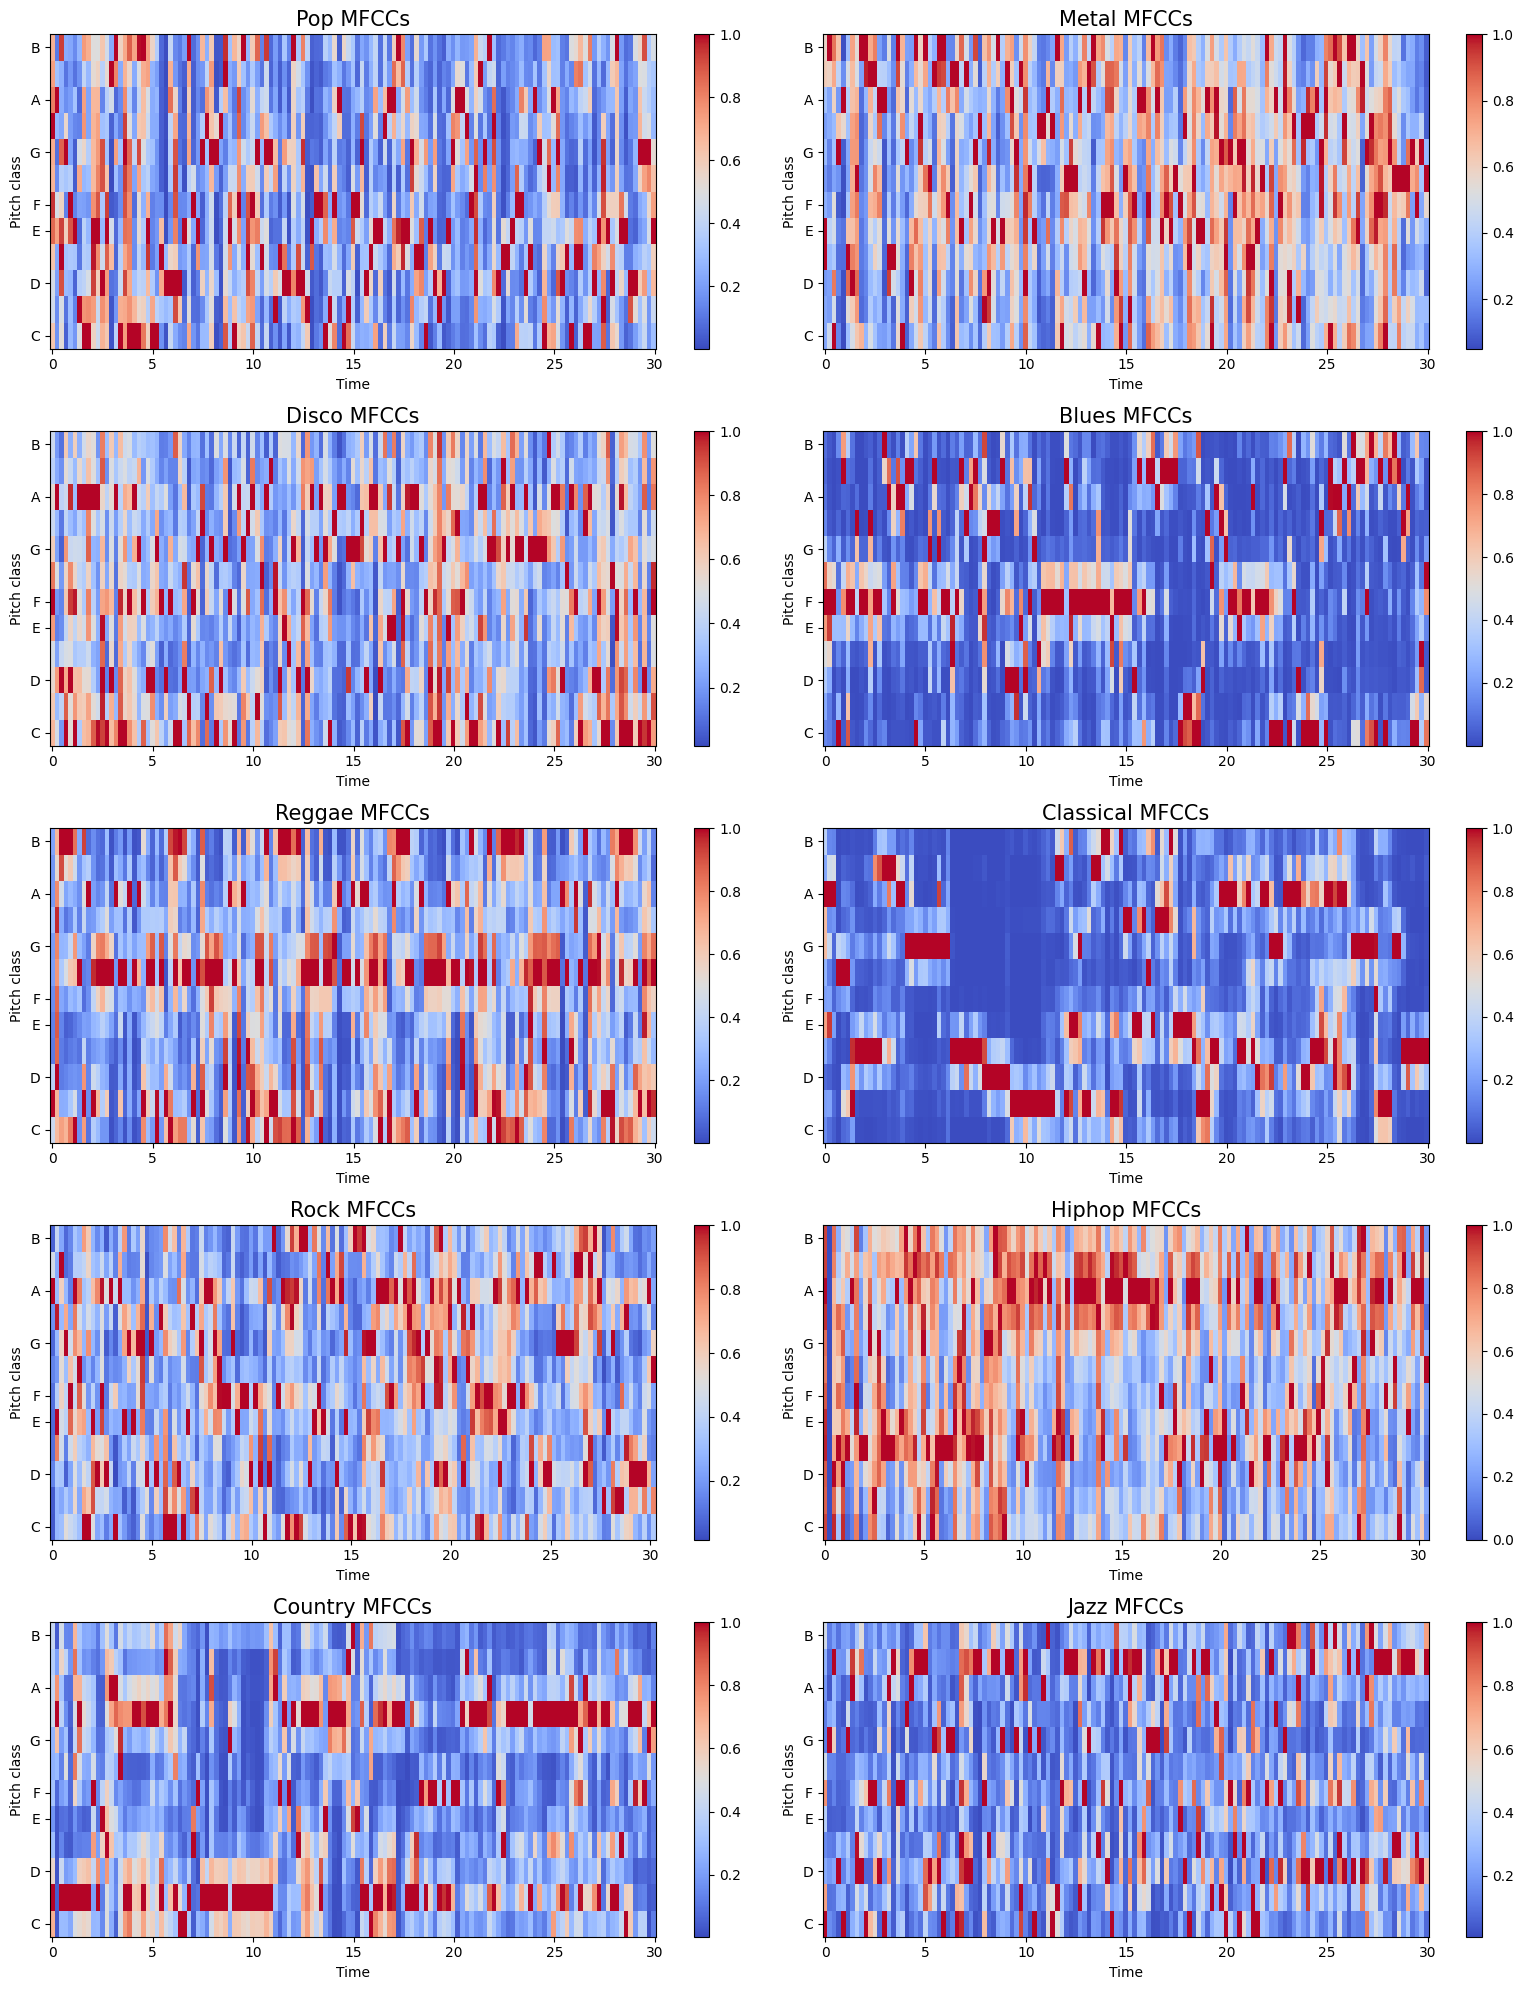

In [9]:
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(16, 20))
hop_length = 5000

for genre, ax in zip(audio.keys(), axes.flatten()):
    chromagram = librosa.feature.chroma_stft(y=audio[genre]['y'], sr=sr, hop_length=hop_length)
    img = librosa.display.specshow(chromagram, sr=audio[genre]['sr'], hop_length=hop_length, x_axis='time', y_axis='chroma', cmap='coolwarm', ax=ax)
    fig.colorbar(img, ax=ax)
    ax.set_title(f"{genre.capitalize()} MFCCs", fontsize=15)

plt.tight_layout()
plt.show()

# **EDA — Exploratory Data Analysis**

'/Users/natallialantukh/.cache/kagglehub/datasets/andradaolteanu/gtzan-dataset-music-genre-classification/versions/1'

In [12]:
data = pd.read_csv(f'{data_path}/features_30_sec.csv')
data.head()

,filename,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,...,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var,label
0,blues.00000.wav,661794,0.350088,0.088757,0.130228,0.002827,1784.165850,129774.064525,2002.449060,85882.761315,...,52.420910,-1.690215,36.524071,-0.408979,41.597103,-2.303523,55.062923,1.221291,46.936035,blues
1,blues.00001.wav,661794,0.340914,0.094980,0.095948,0.002373,1530.176679,375850.073649,2039.036516,213843.755497,...,55.356403,-0.731125,60.314529,0.295073,48.120598,-0.283518,51.106190,0.531217,45.786282,blues
2,blues.00002.wav,661794,0.363637,0.085275,0.175570,0.002746,1552.811865,156467.643368,1747.702312,76254.192257,...,40.598766,-7.729093,47.639427,-1.816407,52.382141,-3.439720,46.639660,-2.231258,30.573025,blues
3,blues.00003.wav,661794,0.404785,0.093999,0.141093,0.006346,1070.106615,184355.942417,1596.412872,166441.494769,...,44.427753,-3.319597,50.206673,0.636965,37.319130,-0.619121,37.259739,-3.407448,31.949339,blues
4,blues.00004.wav,661794,0.308526,0.087841,0.091529,0.002303,1835.004266,343399.939274,1748.172116,88445.209036,...,86.099236,-5.454034,75.269707,-0.916874,53.613918,-4.404827,62.910812,-11.703234,55.195160,blues


In [13]:
mean_cols = [i for i in data.columns if 'mean' in i]
corr = data[mean_cols].corr()
corr.shape


(28, 28)

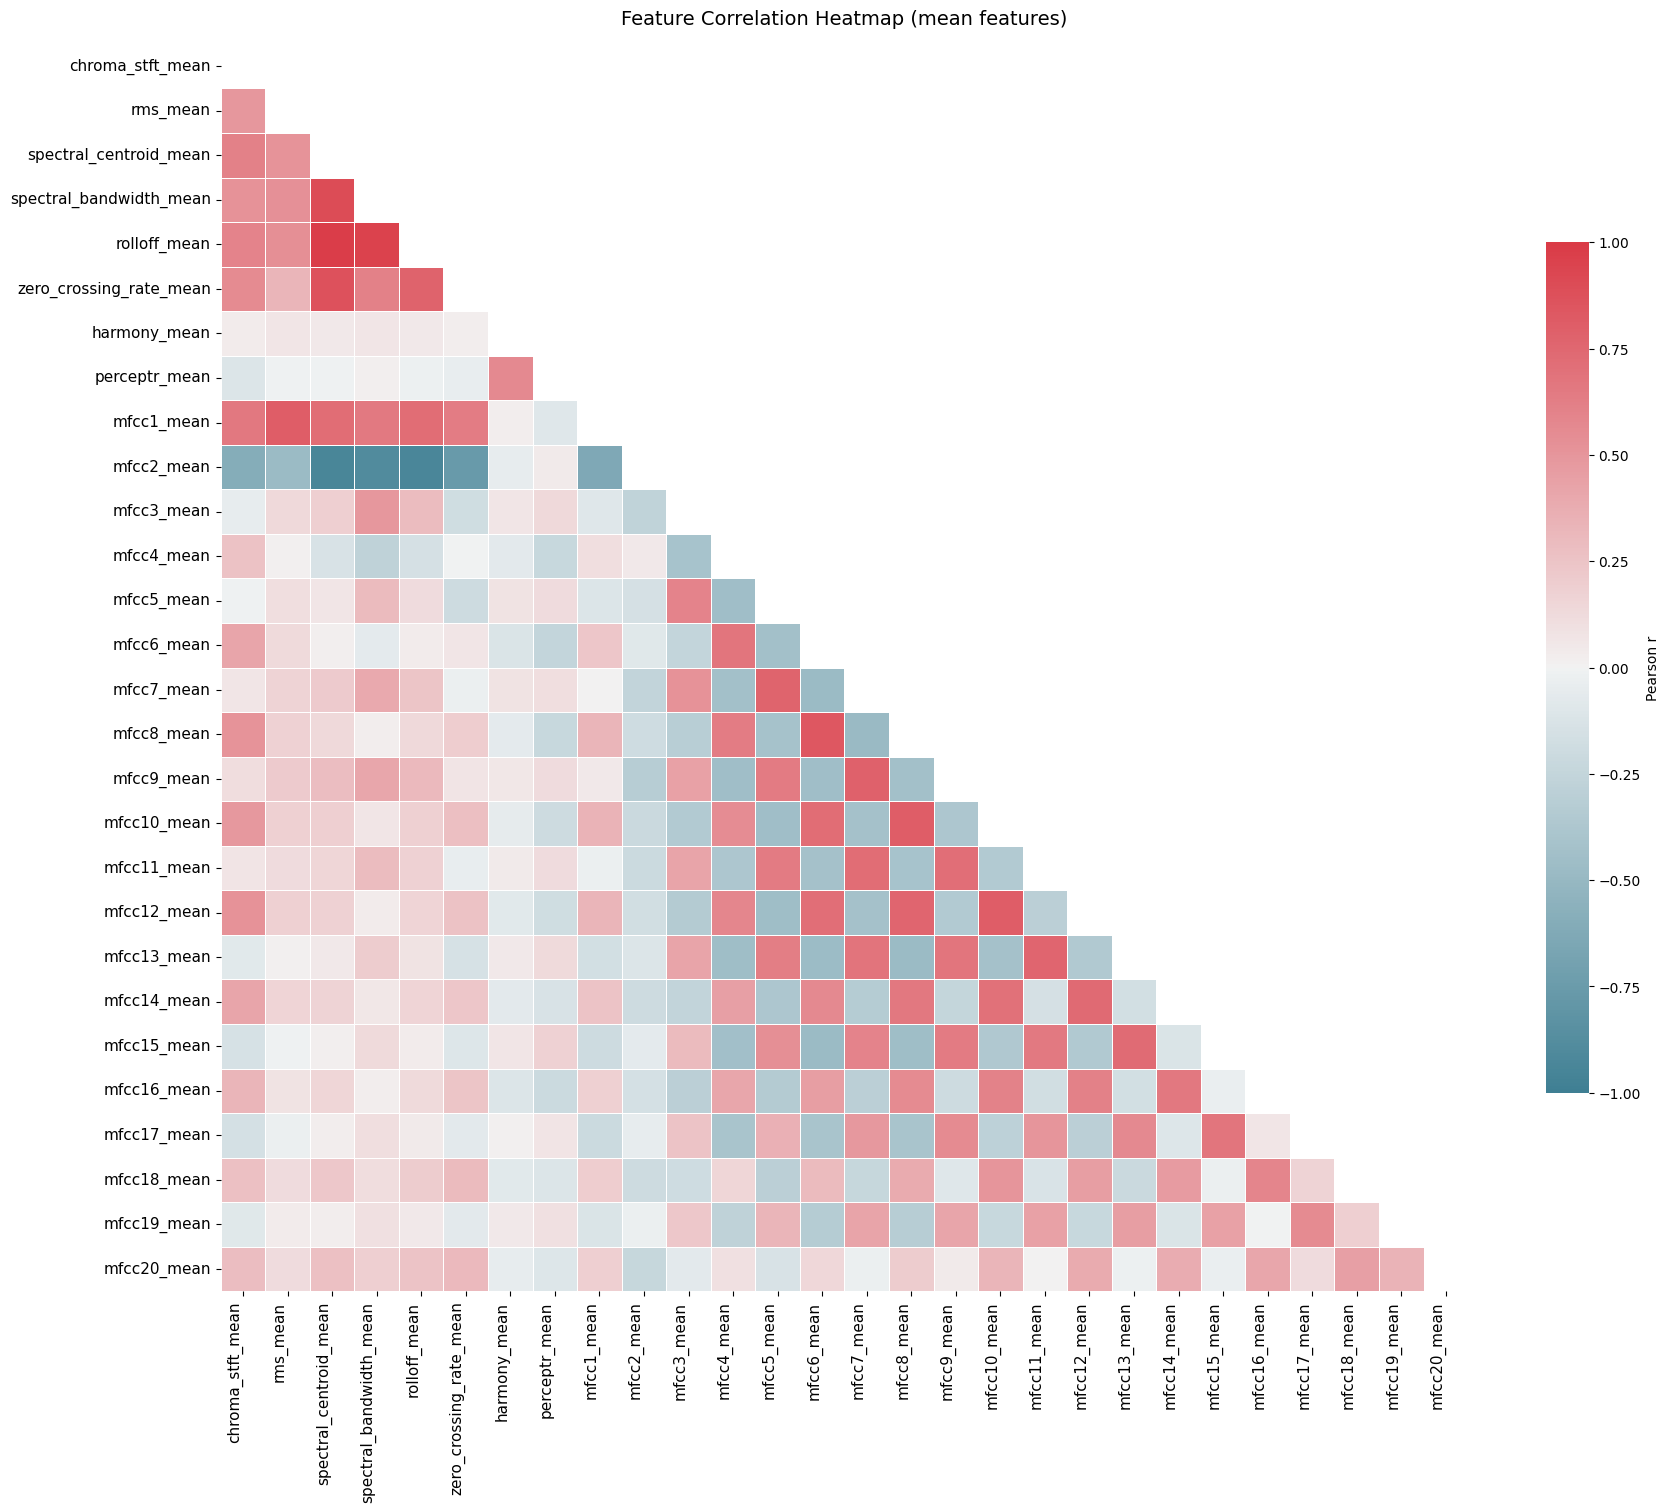

In [14]:
fig, ax = plt.subplots(figsize=(18, 16))

cmap = sns.diverging_palette(220, 10, as_cmap=True)
mask = np.triu(np.ones_like(corr, dtype=bool))  # mask upper triangle → show lower

sns.heatmap(
    corr, mask=mask, cmap=cmap,
    vmin=-1, vmax=1, center=0,
    square=True, linewidths=0.4,
    cbar_kws={"shrink": 0.6, "label": "Pearson r"},
    ax=ax
)

ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='right', fontsize=11)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=11)
ax.set_title("Feature Correlation Heatmap (mean features)", fontsize=14, pad=14)

plt.tight_layout()
plt.savefig("Corr Heatmap.jpg", bbox_inches='tight', dpi=150)
plt.show()

## Heatmap Conclusions

Most feature pairs show weak correlations — the `vmax=0.3` heatmap below is not misleading; most of this dataset genuinely has independent features. That's good news for a classifier. However, **four specific clusters** reveal near-duplicate features worth acting on.

---

### Cluster 1 — "Spectral brightness" block

| Pair | r |
|---|---|
| `spectral_centroid_mean` ↔ `rolloff_mean` | **0.98** |
| `spectral_bandwidth_mean` ↔ `rolloff_mean` | 0.96 |
| `spectral_centroid_mean` ↔ `spectral_bandwidth_mean` | 0.90 |
| `spectral_centroid_mean` ↔ `zero_crossing_rate_mean` | 0.88 |

All four measure the same underlying property: **how much energy lives in high frequencies**. `rolloff_mean` and `spectral_bandwidth_mean` are essentially redundant given `spectral_centroid_mean`.

`zero_crossing_rate_mean` (r=0.88) is kept — it also captures noise and percussion character, not purely spectral brightness.

---

### Cluster 2 — `mfcc2` mirrors the spectral block

| Pair | r |
|---|---|
| `mfcc2_mean` ↔ `spectral_centroid_mean` | −0.94 |
| `mfcc2_mean` ↔ `rolloff_mean` | −0.93 |
| `mfcc2_mean` ↔ `spectral_bandwidth_mean` | −0.90 |

`mfcc2` captures **spectral tilt** (balance between low and high energy) — mathematically the same information as the spectral features, just negated. However, it arrives via a different mathematical basis (DCT), so it's kept: it may encode subtleties the raw spectral features miss.

---

### Cluster 3 — `rms` ↔ `mfcc1` (r = 0.81)

`mfcc1 ≈ log energy`, `rms = energy`. Near-duplicate, but both are kept — `rms` is interpretable loudness; `mfcc1` is the DC component of the cepstrum. Dropping either risks losing the energy dimension entirely.

---

### Cluster 4 — Adjacent even-odd MFCC pairs (r = 0.70–0.84)

`mfcc5↔mfcc7`, `mfcc6↔mfcc8`, `mfcc7↔mfcc9`, etc. This is **structural** — a property of the DCT basis, not a data artefact. Dropping individual MFCCs doesn't help. The right fix is to use fewer coefficients (1–13) or apply PCA to the MFCC block before modelling.

---

### Feature removal decision

| Drop | Keep instead | Reason |
|---|---|---|
| `rolloff_mean` + `rolloff_var` | `spectral_centroid_mean` | r=0.98 — pure redundancy |
| `spectral_bandwidth_mean` + `spectral_bandwidth_var` | `spectral_centroid_mean` | r=0.90 — redundant |

Result: 60 → 56 columns.

In [ ]:
# Drop near-duplicate spectral features
cols_to_drop = ['rolloff_mean', 'spectral_bandwidth_mean']
data_reduced = data.drop(columns=cols_to_drop + [c.replace('mean', 'var') for c in cols_to_drop])

print(f'Original: {data.shape[1]} columns')
print(f'Reduced:  {data_reduced.shape[1]} columns')
print(f'Dropped:  {cols_to_drop + [c.replace("mean", "var") for c in cols_to_drop]}')

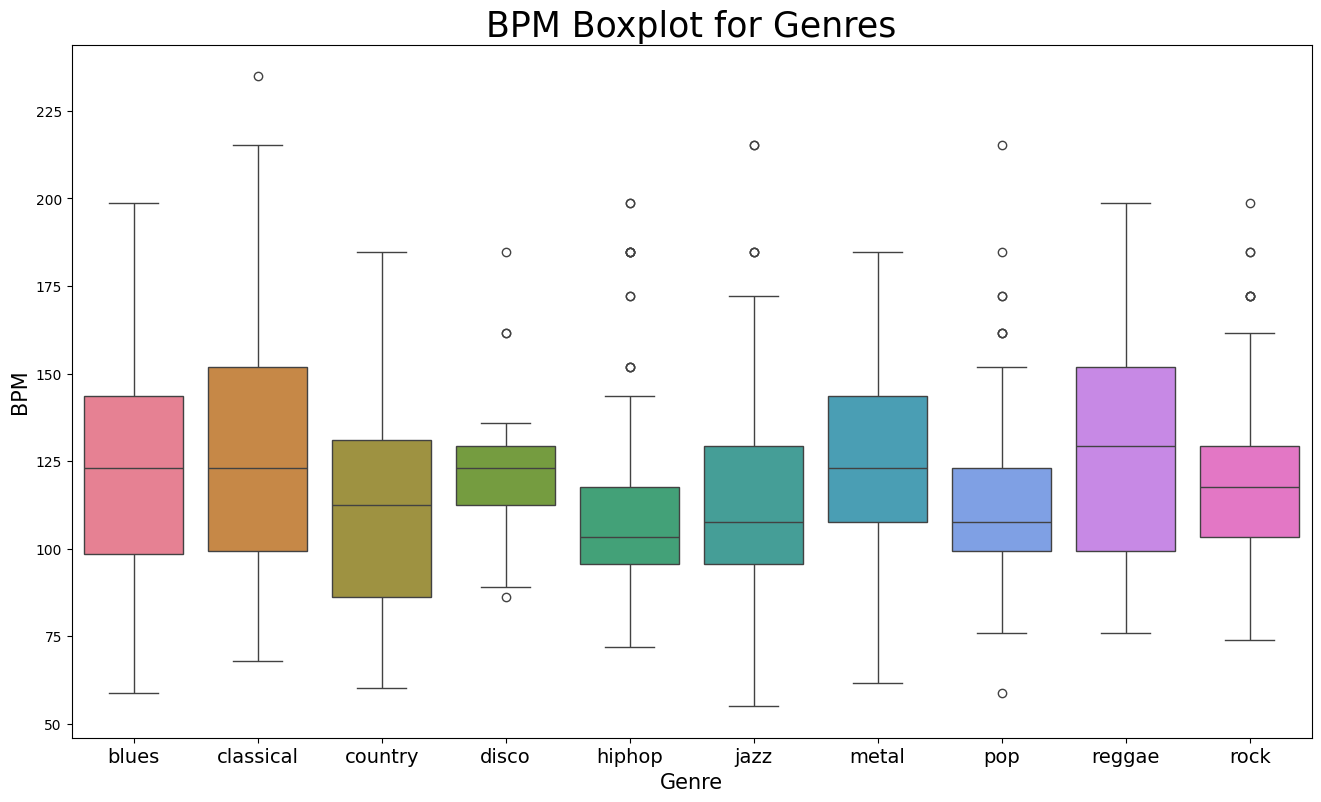

In [38]:

x = data[["label", "tempo"]]

f, ax = plt.subplots(figsize=(16, 9));
sns.boxplot(x = "label", y = "tempo", data = x, palette = 'husl');

plt.title('BPM Boxplot for Genres', fontsize = 25)
plt.xticks(fontsize = 14)
plt.yticks(fontsize = 10);
plt.xlabel("Genre", fontsize = 15)
plt.ylabel("BPM", fontsize = 15)
plt.savefig("BPM Boxplot.jpg")

Principal Component Analysis - to visualize possible groups of genres

In [18]:
from sklearn import preprocessing

data = data.iloc[0:, 1:]
y = data['label']
X = data.loc[:, data.columns != 'label']

In [19]:
#### NORMALIZE X ####

cols = X.columns
min_max_scaler = preprocessing.MinMaxScaler()
X_scaled = min_max_scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=cols)
X_scaled.head()


,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,rolloff_mean,...,mfcc16_mean,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var
0,0.113487,0.362279,0.695468,0.318188,0.101983,0.314117,0.040233,0.422879,0.109789,0.385532,...,0.564186,0.112704,0.541287,0.057615,0.422444,0.082450,0.487950,0.109503,0.599189,0.078255
1,0.113487,0.343622,0.793392,0.230894,0.085580,0.248405,0.121475,0.436889,0.296867,0.353329,...,0.570198,0.120353,0.574685,0.118286,0.448184,0.102997,0.548800,0.099081,0.579640,0.075947
2,0.113487,0.389832,0.640692,0.433652,0.099064,0.254261,0.049046,0.325334,0.095712,0.289224,...,0.622467,0.081898,0.331003,0.085962,0.370988,0.116420,0.453724,0.087317,0.501381,0.045405
3,0.113487,0.473508,0.777954,0.345856,0.229160,0.129376,0.058253,0.267404,0.227566,0.181068,...,0.565151,0.091876,0.484549,0.092509,0.460684,0.068975,0.538690,0.062612,0.468060,0.048168
4,0.113487,0.277759,0.681062,0.219641,0.083075,0.327270,0.110761,0.325514,0.113536,0.357017,...,0.383289,0.200462,0.410225,0.156424,0.403875,0.120300,0.424652,0.130173,0.233047,0.094836


In [20]:
from sklearn.decomposition import PCA

PCA = PCA(n_components=2)
X_pca = PCA.fit_transform(X_scaled)
X_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])

# concatenate with target label
finalDf = pd.concat([X_pca, y], axis = 1)

PCA.explained_variance_ratio_

array([0.2439355 , 0.21781804])

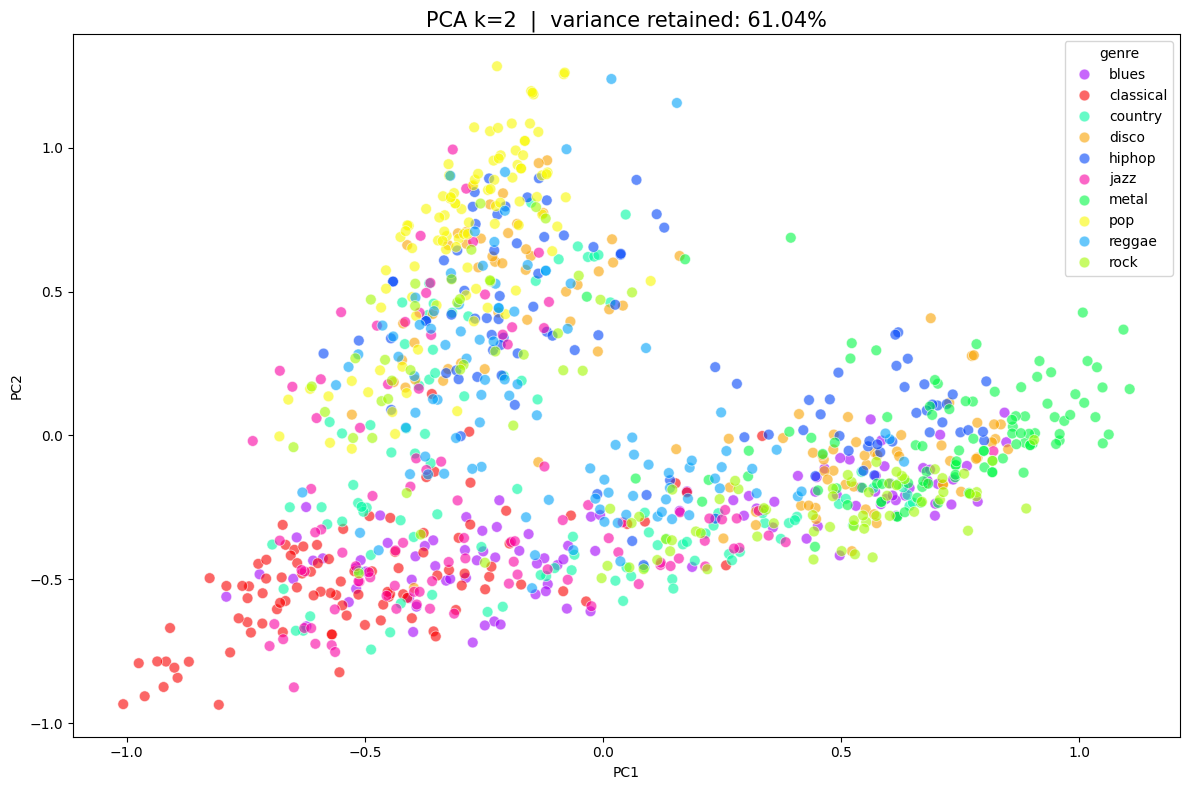

In [49]:
X_pca2 = pd.DataFrame(X_pca2, columns=['PC1', 'PC2'])
X_pca2['genre'] = y.values

fig, ax = plt.subplots(figsize=(12, 8))
sns.scatterplot(
    data=X_pca2,
    x='PC1',
    y='PC2',
    hue='genre',
    palette=color_map,
    alpha=0.6,
    s=60,
    ax=ax
)
ax.set_title(f'PCA k=2  |  variance retained: {var2:.2f}%', fontsize=15)
plt.tight_layout()
plt.show()

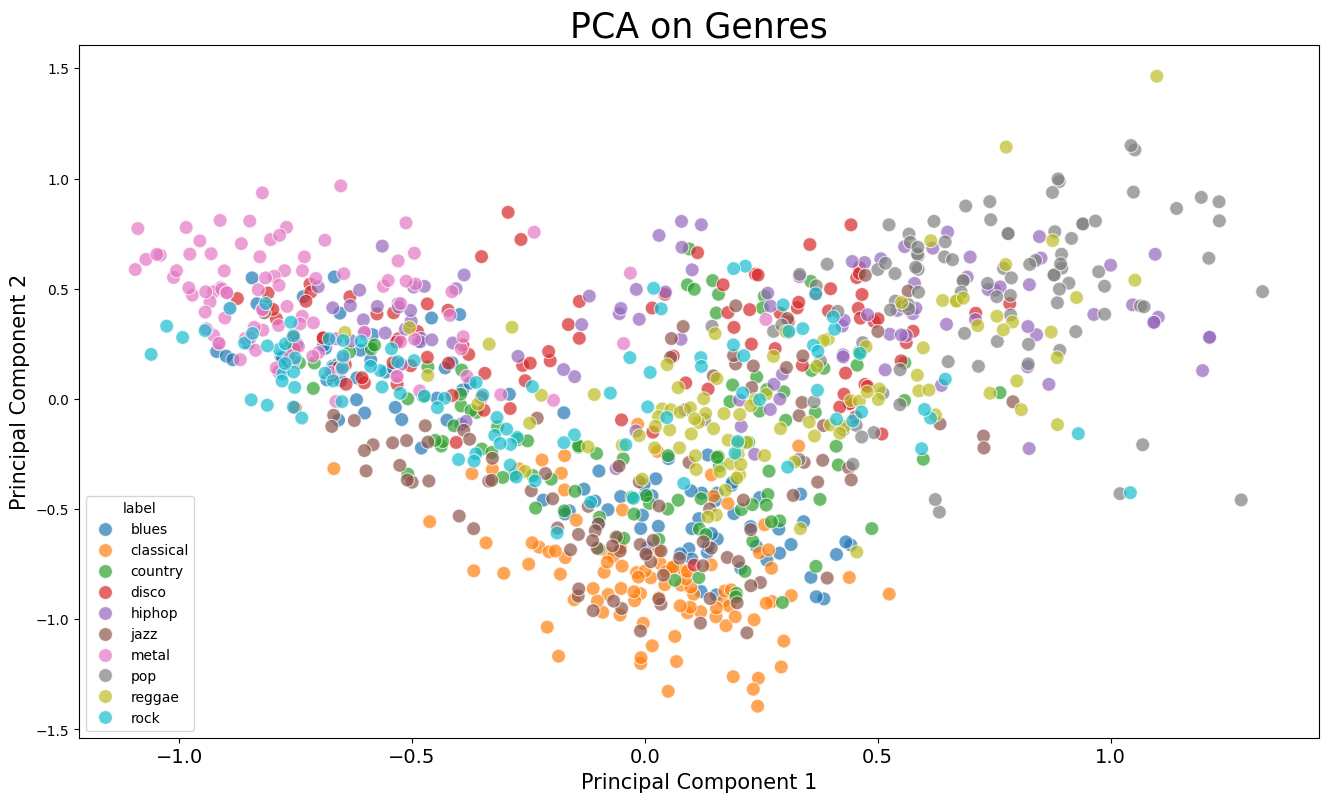

In [21]:
plt.figure(figsize = (16, 9))
sns.scatterplot(x = "PC1", y = "PC2", data = finalDf, hue = "label", alpha = 0.7,
               s = 100);

plt.title('PCA on Genres', fontsize = 25)
plt.xticks(fontsize = 14)
plt.yticks(fontsize = 10);
plt.xlabel("Principal Component 1", fontsize = 15)
plt.ylabel("Principal Component 2", fontsize = 15)
plt.savefig("PCA Scattert.jpg")

In [44]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# --- prepare data ---
X = data[mean_cols]
y = data['label']

scaler = preprocessing.MinMaxScaler()
X_scaled = scaler.fit_transform(X)


# --- PCA k=2 ---
pca2 = PCA(n_components=2)
X_pca2 = pca2.fit_transform(X_scaled)
var2 = sum(pca2.explained_variance_ratio_)*100


X_pca2 = pd.DataFrame(X_pca2, columns=['PC1', 'PC2'])

# concatenate with target label
# finalDf = pd.concat([X_pca2, y], axis = 1)

# --- PCA k=3 ---
pca3 = PCA(n_components=3)
X_pca3 = pca3.fit_transform(X_scaled)
var3 = sum(pca3.explained_variance_ratio_) * 100

print(f'Variance retained (k=2): {var2:.2f}%')
print(f'Variance retained (k=3): {var3:.2f}%')


Variance retained (k=2): 61.04%
Variance retained (k=3): 70.35%


In [45]:
# --- colors and labels ---
genres = data['label'].unique()
color_map = {genre: color for genre, color in zip(genres, colors)}
genre_colors = [color_map[genre] for genre in y]

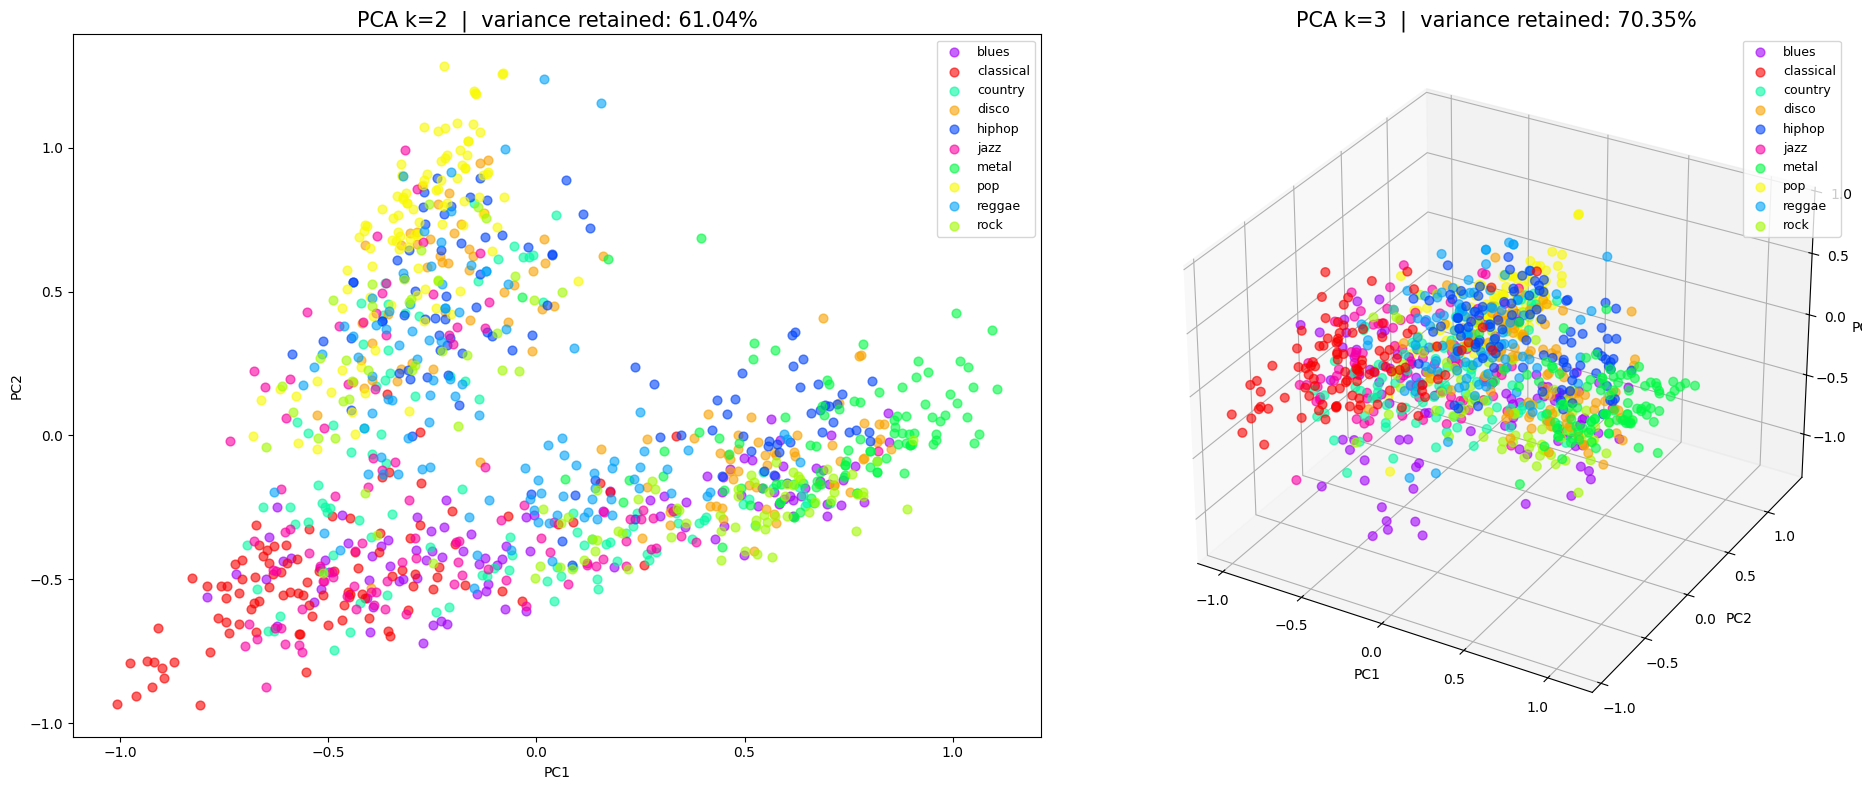

In [47]:
from mpl_toolkits.mplot3d import Axes3D
# --- PCA k=2 ---
pca2 = PCA(n_components=2)
X_pca2 = pca2.fit_transform(X_scaled)
var2 = sum(pca2.explained_variance_ratio_)*100


# X_pca2 = pd.DataFrame(X_pca2, columns=['PC1', 'PC2'])



fig = plt.figure(figsize=(20, 8))

# k=2
ax2 = fig.add_subplot(1, 2, 1)
for genre in genres:
    mask = y == genre
    ax2.scatter(X_pca2[mask, 0], X_pca2[mask, 1],
                color=color_map[genre], label=genre, alpha=0.6, s=40)
ax2.set_title(f'PCA k=2  |  variance retained: {var2:.2f}%', fontsize=15)
ax2.set_xlabel('PC1')
ax2.set_ylabel('PC2')
ax2.legend(loc='best', fontsize=9)

# k=3
ax3 = fig.add_subplot(1, 2, 2, projection='3d')
for genre in genres:
    mask = y == genre
    ax3.scatter(X_pca3[mask, 0], X_pca3[mask, 1], X_pca3[mask, 2],
                color=color_map[genre], label=genre, alpha=0.6, s=40)
ax3.set_title(f'PCA k=3  |  variance retained: {var3:.2f}%', fontsize=15)
ax3.set_xlabel('PC1')
ax3.set_ylabel('PC2')
ax3.set_zlabel('PC3')
ax3.legend(loc='best', fontsize=9)

plt.tight_layout()
plt.show()

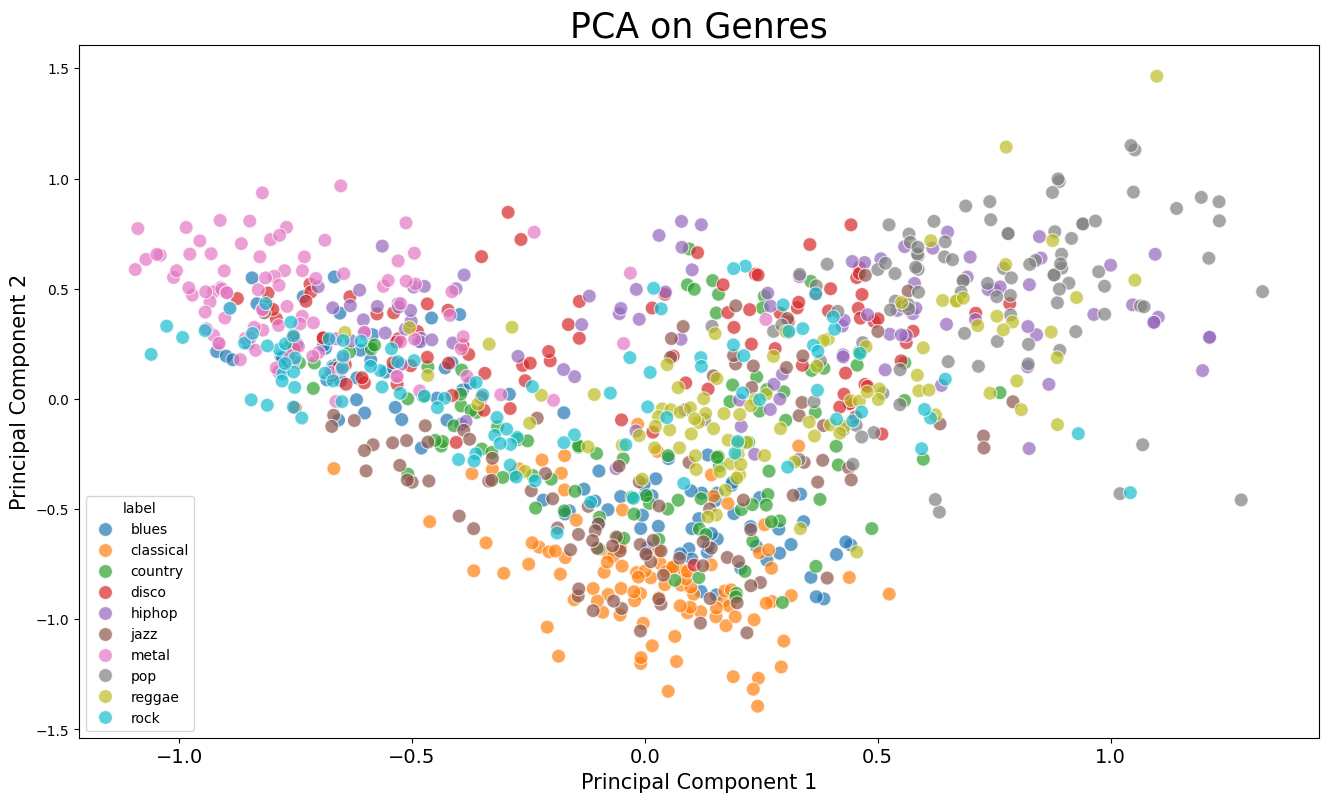

In [43]:
plt.figure(figsize = (16, 9))
sns.scatterplot(x = "PC1", y = "PC2", data = finalDf, hue = "label", alpha = 0.7,
               s = 100);

plt.title('PCA on Genres', fontsize = 25)
plt.xticks(fontsize = 14)
plt.yticks(fontsize = 10);
plt.xlabel("Principal Component 1", fontsize = 15)
plt.ylabel("Principal Component 2", fontsize = 15)
plt.savefig("PCA Scattert.jpg")

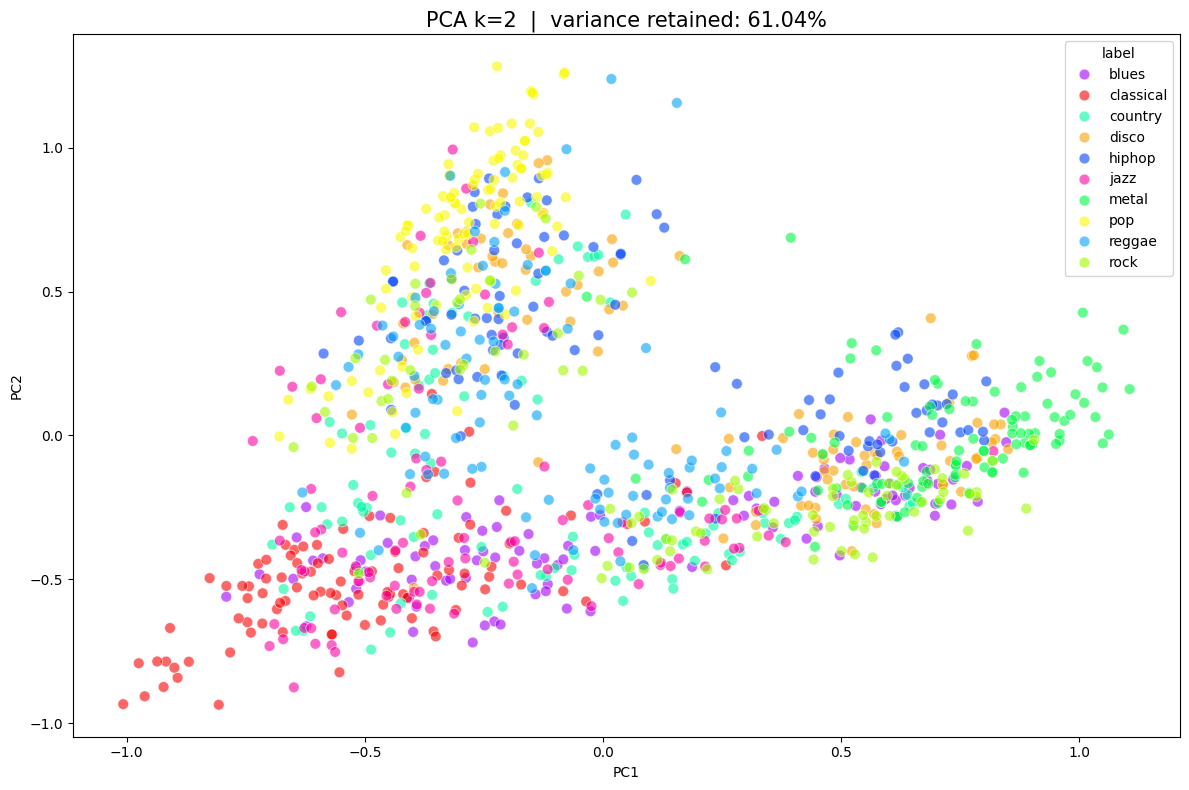

In [40]:
import seaborn as sns

# k=2
fig, ax = plt.subplots(figsize=(12, 8))
sns.scatterplot(
    x=X_pca2[:, 0],
    y=X_pca2[:, 1],
    hue=y,
    palette=color_map,
    alpha=0.6,
    s=60,
    ax=ax
)
ax.set_title(f'PCA k=2  |  variance retained: {var2:.2f}%', fontsize=15)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
plt.tight_layout()
plt.show()

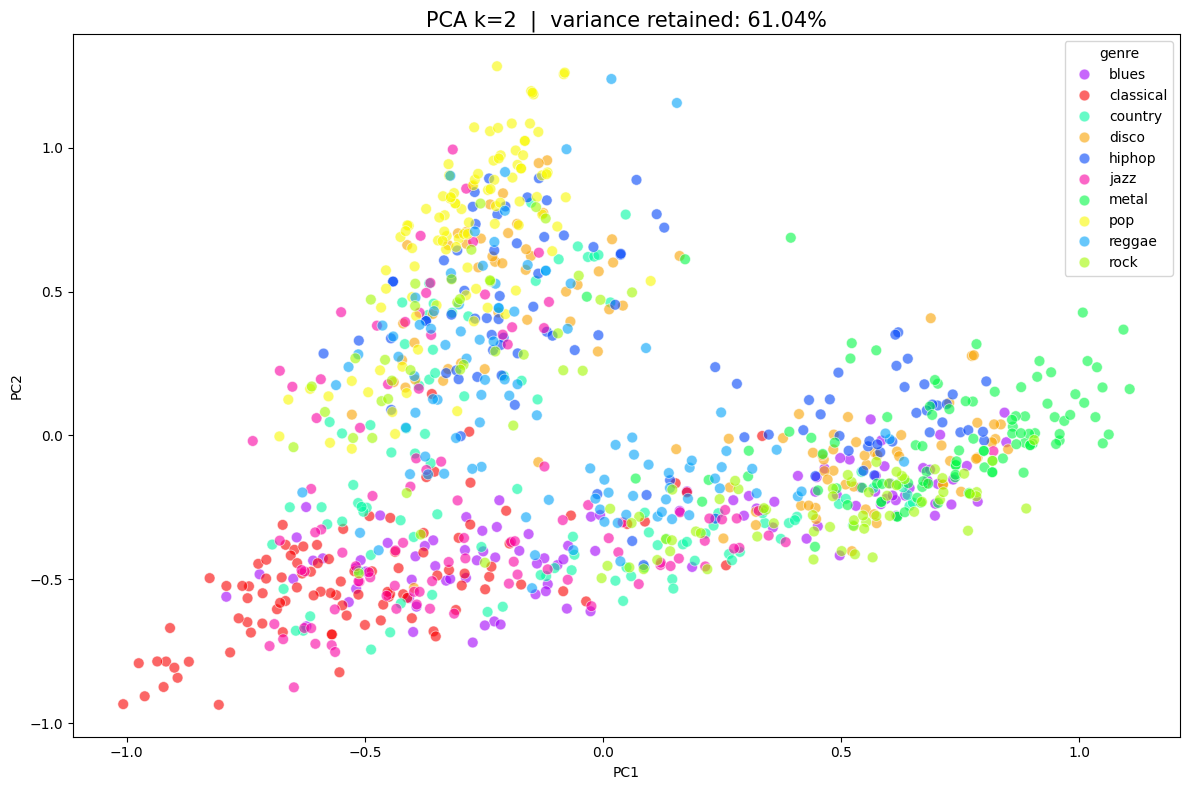

In [48]:
X_pca2 = pd.DataFrame(X_pca2, columns=['PC1', 'PC2'])
X_pca2['genre'] = y.values

fig, ax = plt.subplots(figsize=(12, 8))
sns.scatterplot(
    data=X_pca2,
    x='PC1',
    y='PC2',
    hue='genre',
    palette=color_map,
    alpha=0.6,
    s=60,
    ax=ax
)
ax.set_title(f'PCA k=2  |  variance retained: {var2:.2f}%', fontsize=15)
plt.tight_layout()
plt.show()

The fact that the author capped the scale at 0.3 is itself an interpretation: most correlations in this dataset are weak. This is actually good
  news for classification — the features carry mostly independent information. If correlations were 0.8+, you'd be wasting model capacity on
  redundant inputs.